## Script for testing results on healthy data

## imports

In [8]:

import mne
import numpy as np
import pandas as pd
import os.path as op
from matplotlib import pyplot as plt
import pickle
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import backend as K
import os

#from models import run_kfold_training, CNN_model_contraction_og, CNN_model_contraction_multichan


gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
mne.set_log_level("CRITICAL")

global frq
global window 
global step 

In [9]:
# single head CNN model for number of contractions  
def CNN_model_contraction_multichan(input_shape, num_classes,feature_num):
    global epoch_len
    
    inputs = Input(shape=(epoch_len, feature_num))

    x = Conv1D(16, kernel_size=3, activation='relu', input_shape=input_shape, kernel_regularizer=l2(0.0001))(inputs) # Add a 1D convolutional layer with 32 filters and ReLU activation
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x) # Add a max pooling layer
    x = Conv1D(32, kernel_size=3, activation='relu')(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.3)(x)



    x = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.7)(x)

    x = Flatten()(x)

    # two heads for each label 
    # output head for Zygo
    out_zygo = Dense(num_classes, activation='softmax', name="zygo_output", kernel_regularizer=l2(0.001))(x)

    # output head for Corr
    out_corr = Dense(num_classes, activation='softmax', name="corr_output", kernel_regularizer=l2(0.001))(x)

    model = Model(inputs=inputs, outputs=[out_zygo, out_corr])
    
    return model 

In [10]:
# single head CNN model for number of contractions  
def CNN_model_contraction_og(input_shape, num_classes,feature_num):
    global epoch_len

    model = Sequential([
        Input(shape=(epoch_len, feature_num)) # NEED TO MAKE SHAPE A PARAMETER 
         # binary
    ])

    # Convolutional Layers - 
    model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))  # Add a 1D convolutional layer with 32 filters and ReLU activation
    model.add(MaxPooling1D(pool_size=2))  # Add a max pooling layer

    model.add(Conv1D(64, kernel_size=3, activation='relu'))  # Add another 1D convolutional layer with 64 filters and ReLU activation
    model.add(MaxPooling1D(pool_size=2))  # Add another max pooling layer

    #model.add(Conv1D(128, kernel_size=3, activation='relu'))  # Add another 1D convolutional layer?

    # Flattening Layer
    model.add(Flatten())  # Flatten the output of the convolutional layers


    # Fully Connected Layers - connect each neuron of one layer to other neuron 
    model.add(Dense(128, activation='relu')) # Add a fully connected layer with 128 neurons and ReLU activation
    model.add(Dropout(0.5)) # see if this changes anything? 
    model.add(Dense(num_classes, activation='softmax'))  # Add the output layer with softmax activation


    return model  # Return the compiled model

In [11]:
def classify_muscle(row):
    zygo = row['Num_Contractions_Zygo']
    corr = row['Num_Contractions_Corr']
    
    if zygo > 2 and corr > 2:
        return 'Zygo' if zygo >= corr else 'Corr'
    elif zygo > 2:
        return 'Zygo'
    elif corr > 2:
        return 'Corr'
    else:
        return None



In [12]:

# function for k-fold training 
def run_kfold_training(model_func,X_train_full, X, y,  input_shape, num_classes, feature_num,compile_kwargs, fit_kwargs=None, # arguments fed to model.fit() 
                       n_splits=5,random_state=42, shuffle=True,verbose=1,epoch_num=10,
                         type=1,epoch_len=10): # model type (1: single head count, 2: two head count and duration, 3: two head for zygo and corr, 4: four head) 
   # returns a dictionary with {"models", "histories", "cv_scores"}.     

    if fit_kwargs is None:
        fit_kwargs = {}
    fit_kwargs = fit_kwargs.copy()

 

    kf = KFold(n_splits=n_splits, random_state=random_state, shuffle=shuffle)
    models = []
    histories = []
    cv_scores = []

    fold = 1
    for train_idx, val_idx in kf.split(X_train_full):
        print(f"Fold: {fold} {'='*65}")
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        
        model = model_func(input_shape, num_classes,feature_num)
        model.compile(**compile_kwargs)

        if type ==2:
            history = model.fit(
                    X_train,
                    {"count_output": y_train[:, 0],
                    "duration_output": y_train[:, 1],},
                        validation_data=(X_val,  {
                        "count_output": y_val[:, 0],
                        "duration_output": y_val[:, 1],
                    }
                    ),epochs=epoch_num,
                    verbose=verbose,
                )
            
            scores = model.evaluate(X_val, {
                                    "count_output": y_val[:, 0],
                                    "duration_output": y_val[:, 1],
                                    }, 
                                    return_dict=True)
            
        elif type == 3:
            history = model.fit(
                    X_train,
                    {"zygo_output": y_train[:, 0],
                    "corr_output": y_train[:, 1],},
                        validation_data=(X_val,  {
                        "zygo_output": y_val[:, 0],
                        "corr_output": y_val[:, 1],
                    }
                    ),epochs=epoch_num,
                    )
            
            scores = model.evaluate(X_val, {
            "zygo_output": y_val[:, 0],
            "corr_output": y_val[:, 1],
                },return_dict=True)
            
        elif type == 4:
              history = model.fit(X_train, {
                        'zygo_count_output': y_train[:, 0],
                        'zygo_duration_output': y_train[:, 1],
                        'corr_count_output': y_train[:, 2],
                        'corr_duration_output': y_train[:, 3]
                    }, epochs=epoch_num, validation_data=(
                    X_val,
                    {
                        'zygo_count_output': y_val[:, 0],
                        'zygo_duration_output': y_val[:, 1],
                        'corr_count_output': y_val[:, 2],
                        'corr_duration_output': y_val[:, 3]
                    }
                ), #callbacks=[early_stop])
                )
              
              scores = model.evaluate(X_val,{
                'zygo_count_output': y_val[:, 0],
                'zygo_duration_output': y_val[:, 1],
                'corr_count_output': y_val[:, 2],
                'corr_duration_output': y_val[:, 3]
            }, verbose=0, return_dict=True)
        
        else:
            history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val), epochs=epoch_num,
            #callbacks=[early_stop],
        )
            
            scores = model.evaluate(X_val, y_val, return_dict=True)

        

        fold += 1
        models.append(model)
        histories.append(history)
        cv_scores.append(scores)

    return {
        "models": models,
        "histories": histories,
        "cv_scores": cv_scores,
    }


## Training Single Channel Model

In [14]:
features_all_temp = pd.read_pickle("training_features_18042026.pkl")

muscle_groups = features_all_temp["True_Muscle_Activated"].repeat(2).reset_index(drop=True)
 
X_zygo = features_all_temp[["Zygo"]] 
X_corr = features_all_temp[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([features_all_temp["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all_temp["Num_Contractions_Corr"].astype(int).to_numpy()])       

y_zygo = features_all_temp["Num_Contractions_Zygo"].astype(int).to_numpy()
y_corr = features_all_temp["Num_Contractions_Corr"].astype(int).to_numpy()

y = np.concatenate((y_zygo, y_corr), axis=0)

indices = np.arange(len(X))
idx_train, idx_test, muscle_train, muscle_test = train_test_split(indices, muscle_groups,test_size=0.2, random_state=42) # keep 20% purely for testing 

# split like this to be able to recover the indices for later when rescoring 
X_train_full = X[idx_train]
X_test = X[idx_test]
y_train_full = y[idx_train]
y_test = y[idx_test]

input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X_zygo)[2]
epoch_len = np.shape(X_zygo)[1]

In [ ]:
# call function for training
results_single_head_contraction = run_kfold_training(
    model_func=CNN_model_contraction_og,
    X_train_full=X_train_full,
    X=X,
    y=y,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": "sparse_categorical_crossentropy",
        "metrics": ["accuracy"]
    },
    n_splits=5,
    epoch_len=epoch_len)

model_contraction = results_single_head_contraction["models"][-1]
model_history_contraction = model_contraction.fit(X_train_full, y_train_full, epochs=10, validation_data=(X_test, y_test)) #, callbacks=[early_stop])

Fold: 1 =================================================================
Epoch 1/10
288/288 [==============================] - 9s 28ms/step - loss: 7.6061 - accuracy: 0.7361 - val_loss: 1.0887 - val_accuracy: 0.8672
Epoch 2/10
288/288 [==============================] - 9s 33ms/step - loss: 2.2356 - accuracy: 0.8007 - val_loss: 1.5712 - val_accuracy: 0.8733
Epoch 3/10
288/288 [==============================] - 13s 45ms/step - loss: 3.4350 - accuracy: 0.7974 - val_loss: 4.5660 - val_accuracy: 0.8698
Epoch 4/10
288/288 [==============================] - 10s 34ms/step - loss: 2.2519 - accuracy: 0.8249 - val_loss: 2.6222 - val_accuracy: 0.8681
Epoch 5/10
288/288 [==============================] - 7s 25ms/step - loss: 2.1962 - accuracy: 0.8383 - val_loss: 4.1543 - val_accuracy: 0.8377
Epoch 6/10
288/288 [==============================] - 10s 36ms/step - loss: 2.2249 - accuracy: 0.8498 - val_loss: 4.3198 - val_accuracy: 0.8650
Epoch 7/10
288/288 [==============================] - 9s 30ms/ste

In [17]:
features_all_healthy = pd.read_pickle("subj_healthy.pkl")

 
X_zygo = features_all_healthy[["Zygo"]] 
X_corr = features_all_healthy[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([features_all_healthy["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all_healthy["Num_Contractions_Corr"].astype(int).to_numpy()])       

y_zygo = features_all_healthy["Num_Contractions_Zygo"].astype(int).to_numpy()
y_corr = features_all_healthy["Num_Contractions_Corr"].astype(int).to_numpy()

y = np.concatenate((y_zygo, y_corr), axis=0)

In [26]:

# full training results (test data not seen during cross val)
y_pred_train = model_contraction.predict(X)  
y_pred_train = np.argmax(y_pred_train, axis=1)   

# Calculate accuracy
accuracy_training = accuracy_score(y, y_pred_train)   
f1_training = f1_score(y, y_pred_train, average='weighted')  

# zygo 
y_pred_train_zygo = model_contraction.predict(X_zygo)  
y_pred_train_zygo = np.argmax(y_pred_train_zygo, axis=1)   

accuracy_training_zygo = accuracy_score(y_zygo, y_pred_train_zygo)   
f1_training_zygo = f1_score(y_zygo, y_pred_train_zygo, average='weighted')  

# corr
y_pred_train_corr = model_contraction.predict(X_corr)  
y_pred_train_corr = np.argmax(y_pred_train_corr, axis=1)   
accuracy_training_corr = accuracy_score(y_corr, y_pred_train_corr)   
f1_training_corr = f1_score(y_corr, y_pred_train_corr, average='weighted')  

# Print accuracy and F1 score
print("Model scores---------------")
print("Accuracy :", accuracy_training)  
print("F1 Score :", f1_training)   

print("\nCorr Results-------------------")
print("Accuracy:", accuracy_training_corr)
print("F1 Score :", f1_training_corr)   

print("\nZygo Results-------------------")
print("Accuracy :", accuracy_training_zygo)  
print("F1 Score :", f1_training_zygo)   


10/10 [==============================] - 0s 6ms/step
Model scores---------------
Accuracy : 0.8733333333333333
F1 Score : 0.850842593201394

Corr Results-------------------
Accuracy: 0.8433333333333334
F1 Score : 0.8164698075646981

Zygo Results-------------------
Accuracy : 0.9033333333333333
F1 Score : 0.8840108908079577


## Training Multi-Channel Model

In [27]:
# Define CNN model inputs 
muscle_groups = features_all_temp["True_Muscle_Activated"].repeat(2).reset_index(drop=True)

X_zygo = features_all_temp[["Zygo"]] 
X_corr = features_all_temp[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

X = np.concatenate((X_zygo, X_corr), axis=2) # feeding in two channels 


y = np.transpose([features_all_temp["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all_temp["Num_Contractions_Corr"].astype(int).to_numpy()])




indices = np.arange(len(X))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42) # keep 20% purely for testing 

# split like this to be able to recover the indices for later when rescoring 
X_train_full = X[idx_train]
X_test = X[idx_test]
y_train_full = y[idx_train]
y_test = y[idx_test]

input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X)[2]
epoch_len = np.shape(X)[1]


In [28]:
two_channel_contraction = run_kfold_training(
    model_func=CNN_model_contraction_multichan,
    X_train_full=X_train_full,
    X=X,
    y=y,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": {
            "zygo_output": "sparse_categorical_crossentropy",
            "corr_output": "sparse_categorical_crossentropy",
        },
        "metrics": {
            "zygo_output": ["accuracy"],
            "corr_output": ["accuracy"],
        },
    },
    epoch_len = epoch_len,
    fit_kwargs={"epochs": 10},
    n_splits=5,
    type=3)

model_two_channel_contraction = two_channel_contraction["models"][-1]
cvScores = two_channel_contraction["cv_scores"]

model_history_twochannel_dur = model_two_channel_contraction.fit(X_train_full, [y_train_full[:, 0],y_train_full[:, 1]], epochs=10, validation_data=(X_test, [y_test[:, 0],y_test[:, 1]])) #, callbacks=[early_stop])

Fold: 1 =================================================================
Epoch 1/10
144/144 [==============================] - 24s 146ms/step - loss: 2.5288 - zygo_output_loss: 1.2080 - corr_output_loss: 1.2353 - zygo_output_accuracy: 0.7871 - corr_output_accuracy: 0.7600 - val_loss: 1.8902 - val_zygo_output_loss: 0.8783 - val_corr_output_loss: 0.9164 - val_zygo_output_accuracy: 0.8698 - val_corr_output_accuracy: 0.8194
Epoch 2/10
144/144 [==============================] - 19s 129ms/step - loss: 1.4467 - zygo_output_loss: 0.6514 - corr_output_loss: 0.6893 - zygo_output_accuracy: 0.8453 - corr_output_accuracy: 0.8362 - val_loss: 1.4306 - val_zygo_output_loss: 0.6086 - val_corr_output_loss: 0.7056 - val_zygo_output_accuracy: 0.8550 - val_corr_output_accuracy: 0.8255
Epoch 3/10
144/144 [==============================] - 12s 86ms/step - loss: 1.2800 - zygo_output_loss: 0.5635 - corr_output_loss: 0.5943 - zygo_output_accuracy: 0.8505 - corr_output_accuracy: 0.8431 - val_loss: 1.3313 - val_

In [30]:

 
X_zygo = features_all_healthy[["Zygo"]] 
X_corr = features_all_healthy[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 


X = np.concatenate((X_zygo, X_corr), axis=2) # feeding in two channels 
y = np.transpose([features_all_healthy["Num_Contractions_Zygo"].astype(int).to_numpy(),
                    features_all_healthy["Num_Contractions_Corr"].astype(int).to_numpy()])




In [32]:

# full training results (test data not seen during cross val)
y_pred_train_zygo, y_pred_train_corr = model_two_channel_contraction.predict(X)
y_pred_train_zygo = np.argmax(y_pred_train_zygo, axis=1)
y_pred_train_corr = np.argmax(y_pred_train_corr, axis=1)

# true labels for corr and zygo 
y_train_zygo = y[:, 0]
y_train_corr = y[:, 1]


# calculate accuracy for each muscle group 
accuracy_train_zygo_tc = accuracy_score(y_train_zygo, y_pred_train_zygo)
accuracy_train_corr_tc = accuracy_score(y_train_corr, y_pred_train_corr)

# calculate f1 score for each muscle group 
f1_train_zygo_tc = f1_score(y_train_zygo, y_pred_train_zygo, average='weighted')
f1_train_corr_tc = f1_score(y_train_corr, y_pred_train_corr, average='weighted')
 
print("-------- Zygo --------")
print(" Accuracy:", accuracy_train_zygo_tc)
print(" F1 Score:", f1_train_zygo_tc)

print("\n -------- Corr --------")
print(" Accuracy:", accuracy_train_corr_tc)
print(" F1 Score:", f1_train_corr_tc)

# average score
print("\n -------- Average --------")
print(" Accuracy:", (accuracy_train_zygo_tc + accuracy_train_corr_tc) / 2)
print(" F1 Score:", (f1_train_zygo_tc + f1_train_corr_tc) / 2)


10/10 [==============================] - 0s 16ms/step
-------- Zygo --------
 Accuracy: 0.88
 F1 Score: 0.8584155713567478

 -------- Corr --------
 Accuracy: 0.7466666666666667
 F1 Score: 0.6802323892519971

 -------- Average --------
 Accuracy: 0.8133333333333334
 F1 Score: 0.7693239803043725


## Plotting Results

<module 'matplotlib.pyplot' from '/Users/zeynepozkaya/anaconda3/envs/tf_gpu/lib/python3.10/site-packages/matplotlib/pyplot.py'>

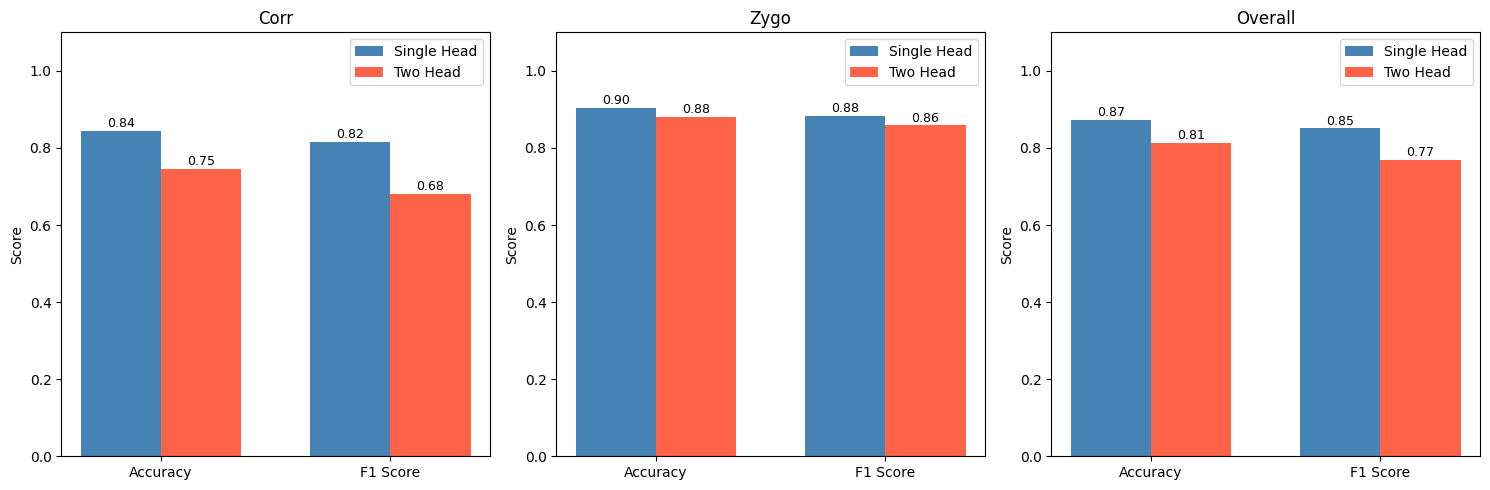

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'F1 Score']
x = np.arange(len(metrics))
width = 0.35

# [accuracy, f1] for each model
m1_corr    = [accuracy_training_corr,                              f1_training_corr]
m2_corr    = [accuracy_train_corr_tc,                              f1_train_corr_tc]

m1_zygo    = [accuracy_training_zygo,                              f1_training_zygo]
m2_zygo    = [accuracy_train_zygo_tc,                              f1_train_zygo_tc]

m1_overall = [accuracy_training,                                   f1_training]
m2_overall = [(accuracy_train_zygo_tc + accuracy_train_corr_tc)/2, (f1_train_zygo_tc + f1_train_corr_tc)/2]

configs = [
    ('Corr',    m1_corr,    m2_corr,    axes[0]),
    ('Zygo',    m1_zygo,    m2_zygo,    axes[1]),
    ('Overall', m1_overall, m2_overall, axes[2]),
]

for title, m1_scores, m2_scores, ax in configs:
    b1 = ax.bar(x - width/2, m1_scores, width, label='Single Head', color='steelblue')
    b2 = ax.bar(x + width/2, m2_scores, width, label='Two Head',    color='tomato')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.legend()
    for bar in [*b1, *b2]:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt

## Pre-processing data 

In [ ]:
global frq
global window 
global step 

In [ ]:
to_keep=['Fp1', 'Fp2', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'O1', 'O2','EOG1','EOG2','Corr', 'Zygo', 'Menton','Trigger']
eeg_ch= ['Fp1', 'Fp2', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'O1', 'O2']
emg_ch= ['Corr', 'Zygo', 'Menton'] # Menton is chin EMG for sleep scoring
eog_ch= ['EOG1', 'EOG2']
trigger_ch= ['Trigger']

inter_trigger_length = 30
num_epochs = 60 # 60 epochs for each session 
subject_exclude = ["SS01AH Data"] 

subject_list=  ['NL01SS','NL02IF','NL03JV','NL04NF','NL05WW','NL06DJ','RL01AN','RL02GC','RL03JG','RL04VF','RL05JP',
              'RL06FM','RL07BR','RL08AE','RL09PC','RL10TV', 'RL12JL','RL13MT','RL14LT','RL15CL',
              'RL17CA','RL19RS','RL20EM','RL21MB','RL22AC','RL23ET','RL24DD']



raw_path= "/Users/zeynepozkaya/Desktop/SoundSleep/Python_Scripts/EDF_healthy_participants"

current_index=0
inter_trigger_length=10
window = 50 
step = 1 

In [ ]:
# pre-processes data for each subject and returns df with session divided into 60 epochs w meta-data attached 
def pre_process_subjets(subject):
    global raw_path
    global frq

    subject_name = subject
    file= op.join(raw_path,'{}.edf'.format(subject_name))
    raw =  mne.io.read_raw_edf(file,preload=True)

    if 'Fp1/F3' in raw.info['ch_names']:
        mne.rename_channels(info=raw.info,mapping={'Fp1/F3':'Fp1' ,'Fp2/F4':'Fp2'})
        
    if '36' in raw.info['ch_names']:
        mne.rename_channels(info=raw.info,mapping={'36':'Corr' ,'37':'Zygo','38':'Menton'})

    if 'E1' in raw.info['ch_names']:
        mne.rename_channels(info=raw.info,mapping={'E1':'EOG1' ,'E2':'EOG2'})
    
    if 'Corru' in raw.info['ch_names']:
        raw.rename_channels({'Corru': 'Corr'})


    for ch in raw.info['ch_names']:
        if ch not in to_keep:
            raw.drop_channels([ch]) # only keeps channel that contains the trigger (where a stimulus was presented )

    raw.set_channel_types(mapping={'Corr':'emg','Zygo':'emg','Menton':'emg','Trigger':'stim','EOG1':'eog','EOG2':'eog'})

    raw= raw.resample(sfreq=250)

    filter_params_emg = {'lpass': 100,'hpass': 10,'notches': [50]}
    raw.filter(l_freq=filter_params_emg['hpass'],h_freq=filter_params_emg['lpass'],picks=emg_ch)
    filter_params_eeg_eog = {'lpass': 70,'hpass': 0.3,'notches': [50]}
    raw.filter(l_freq=filter_params_eeg_eog['hpass'],h_freq=filter_params_eeg_eog['lpass'],picks=eeg_ch+eog_ch)
    raw.notch_filter(filter_params_eeg_eog['notches'], method='fft', picks=emg_ch+eeg_ch+eog_ch)

    frq=raw.info['sfreq']

    # create dataframe based on events 
    events_all= mne.find_events(raw) # Get all the events (triggers) in your EEG data
    events= mne.pick_events(events_all,include=[201,202]) # Pick events of interest (where a stimulus was presented)

    df_triggers=pd.DataFrame(data=events,columns=['Time(Sample)','dunno','Trigger'])
    df_triggers.drop(columns=['dunno'],inplace=True)
    df_triggers['Time(s)']=df_triggers['Time(Sample)']/raw.info['sfreq']


    # incorporating meta_data 
    cols_inc = ["Subject","Nap_ID","Trigger", "Expected_Muscle","Nb_Corr","Nb_Zygo","Expected_Muscle"] # columns with relevant information from dataframe 
    trial_info = pd.read_csv("Trial_information_healthy_participants.csv", usecols=cols_inc) 
    expected_muscle = ["Corr", "Zygo"]


 
    epochs = mne.Epochs(raw, events, tmin=-0, tmax=9,baseline=None, detrend=0,
                    reject=None, preload=True, on_missing='warn')

   

    epochs.metadata = trial_info[(trial_info["Subject"] == subject.split(" ")[0]) 
                                & (trial_info["Trigger"].isin([201.0, 202.0]))]



    return epochs, df_triggers 

In [ ]:
def make_features_df(subject_epoch,subject):
    features = pd.DataFrame(
        index=range(num_epochs),
        columns=[
            "Subject",
            "Nap_ID",
            "Triggers_Order_Nap", # epochs 
            "Muscle Expected",
            "Num_Contractions_Zygo",
            "Num_Contractions_Corr",
            "Zygo", # processed EMG signal for epoch 
            "Corr"
        ]
        )   
    
    epoch = 0
    for t in range(len(subject_epoch)): 
        # extract epoch  
        epoch_zygo = np.squeeze(subject_epoch[t].get_data(picks=['Zygo']))
        epoch_corr = np.squeeze(subject_epoch[t].get_data(picks=['Corr']))

        nap_id = (t // 60) + 1
        epoch = (t % 60) + 1

        # fill dataframe 

        features.loc[t] = [
            subject, 
            nap_id,
            epoch,
            subject_epoch.metadata['Expected_Muscle'].iloc[0],
            subject_epoch.metadata.iloc[t]["Nb_Zygo"],
            subject_epoch.metadata.iloc[t]["Nb_Corr"],
            epoch_zygo,
            epoch_corr
        ]
        epoch += 1 

    
    return features

In [ ]:
# extracting features for classification 
i = 0 
excl = 0 # count which subjects had to be excluded 

features_results_mat = []

for root,dirs,files in os.walk(raw_path):
    for file in files:
        if "dpa" not in file and ".DS_Store" not in file: # so only take each subject once 
            subject = file.split(".")[0]
            print(subject)


            if subject not in subject_exclude:
                subject_epoch,_ = pre_process_subjets(subject)
                i += 1
                
                # make features data frame for each subject
                features = make_features_df(subject_epoch,subject)
                features_results_mat.append(features)

           

print(f"{i} trials processed, {excl} trials excluded")

In [ ]:
features_all = pd.concat(features_results_mat, ignore_index=True) # potentially save to excel and load in 

In [ ]:
features.to_pickle("subj_healthy.pkl")

In [ ]:
features_all.head()

## Test Model 

In [ ]:
# Define CNN model inputs 
epoch_num = 10 
X_zygo = features_all[["Zygo"]] 
X_corr = features_all[["Corr"]]

X_zygo = X_zygo.to_numpy()
X_zygo = np.array(X_zygo.tolist())
X_zygo = np.transpose(X_zygo, (0, 2, 1)) # setting dimensions 

X_corr = X_corr.to_numpy()
X_corr = np.array(X_corr.tolist())
X_corr = np.transpose(X_corr, (0, 2, 1)) # setting dimensions 

y_zygo = features_all["Num_Contractions_Zygo"].astype(int).to_numpy()
y_corr = features_all["Num_Contractions_Corr"].astype(int).to_numpy()


X = np.concatenate((X_zygo, X_corr), axis=0)
y = np.concatenate([y_zygo, y_corr])       



input_shape = X_train_full.shape[1:]   
num_classes = len(np.unique(y))    

input_shape = (input_shape[0], 1)   
feature_num = np.shape(X_zygo)[2]
epoch_len = np.shape(X_zygo)[1]

In [ ]:
two_channel_contraction = run_kfold_training(
    model_func=CNN_model_contraction_multichan,
    X_train_full=X_train_full,
    X=X,
    y=y,
    input_shape=input_shape,
    num_classes=num_classes,
    feature_num=feature_num,
    compile_kwargs={
        "optimizer": "adam",
        "loss": {
            "zygo_output": "sparse_categorical_crossentropy",
            "corr_output": "sparse_categorical_crossentropy",
        },
        "metrics": {
            "zygo_output": ["accuracy"],
            "corr_output": ["accuracy"],
        },
    },
    fit_kwargs={"epochs": 10},
    n_splits=5)

model_two_channel_contraction = two_channel_contraction["models"][-1]
cvScores = two_channel_contraction["cv_scores"]

model_history_twochannel_dur = model_two_channel_contraction.fit(X_train_full, [y_train_full[:, 0],y_train_full[:, 1]], epochs=epoch_num, validation_data=(X_test, [y_test[:, 0],y_test[:, 1]])) #, callbacks=[early_stop])

In [ ]:
# full training results (test data not seen during cross val)
y_pred_healthy = model_contraction.predict(X_corr)  
y_pred_healthy = np.argmax(y_pred_healthy, axis=1)   



# Calculate accuracy
accuracy_healthy = accuracy_score(y_corr, y_pred_healthy)   

# Calculate F1 score
f1_healthy = f1_score(y_corr, y_pred_healthy, average='weighted')  

# Print accuracy and F1 score
print("Model scores---------------")
print("Accuracy :", accuracy_healthy)  
print("F1 Score :", f1_healthy)   
